# Introduction

The mnist database contains 70,000 images of hand-written digits which are 28 x 28 pixels. This database is often used to explore machine learning classification algoritms. We explore 3 algorithms below: k-nearest neighbors, logistic regression, and a neural network. We will examine each algorithm to find the most efficient training parameters and the best performing model overall in terms of accuracy and efficiency. We start by importing the data the required and the necessary Python libraries.

# Import Libraries

In [68]:
import numpy as np   # numpy arrays used to handle machine learning data
from keras.datasets import mnist    # this gives us access to the mnist dataset
from keras.utils import to_categorical  # allow us to perform encoding of data labels
import matplotlib.pyplot as plt      # used to plot training data for analysis

# Import Data

In [2]:
VALIDATION_SPLIT=0.2
RESHAPED = 784
NB_CLASSES = 10
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(60000, RESHAPED)
X_test = X_test.reshape(10000, RESHAPED)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# normalize
X_train /= 255
X_test /= 255
# convert class vectors to binary class matrices
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

# K-Nearest Neighbors

Machine learning data is encoded in a vector containing numeric data before being used in machine learning. These vectors can be thought of as points, usually in a hyper-dimensional space. Similar data points tend to form clusters. When categorical labels are applied to this data, we can categorize new unlabled by data by identifying which cluster it is closest to. The k-nearest neighbors algorithm calculates the distance between the new data point and each data point in the data set. The nearest k points are identified, and the labels of these nearby points are counted. The most frequent category observed is given to the new data point. We will explore the impact on the number of data points in the training set, the number of nearby ponits considered (k), and the formula used for calculating distance.

## Define Distances

We will first consider the euclidean distance. This is the distance formula that is most often used for determing the distance between two points in space given by the formula $$d(x,y)=\sqrt{\sum_{i=1}^n(y_i-x_i)^2}$$ The function defined below will give us the distance between two points using the Euclidean distance.

In [3]:
def euclid_distance(point1, point2):
    sum = 0
    for i in range(len(point1)):
        sum += (point1[i] - point2[i])**2
    return sum ** (1/2)

Next we will consider the cosine distance. The cosine of the angle between the two vectors that define the points we wish to consider gives us an idea of how similar the points are. We are interested in the dissimalarity of the vectors known as the cosine distance. $$\text{cosine distance} = 1 - \text{cosine similarity}$$ The cosine of the angle between two vectors A and B is calculated as $$\frac{A\cdot B}{||A||\text{ }||B||}$$ Therefore, the cosine distance can be calculated as $$\text{cosine distance} = 1 - \frac{A\cdot B}{||A||\text{ }||B||}$$ The function below performs this calculation.

In [4]:
def cosine_distance(point1, point2):
    # compute the dot product
    dot_product = 0
    for i in range(len(point1)):
        dot_product += (point1[i] * point2[i])
    # calculate the vector norm
    vector_norm_sum_1 = 0
    vector_norm_sum_2 = 0
    for i in range(len(point1)):
        vector_norm_sum_1 += point1[i] ** 2
        vector_norm_sum_2 += point2[i] ** 2
    vector_norm_1 = vector_norm_sum_1 ** (1/2)
    vector_norm_2 = vector_norm_sum_2 ** (1/2)

    # Calculate cosine similarity
    cosine_similarity = dot_product / (vector_norm_1 * vector_norm_2)

    # return cosine distance
    return 1 - cosine_similarity

## K-Nearest Neighbors Algorithm

Below we implement the algorithm using one of the above defined distances.

In [5]:
def k_nearest_neighbors(new_point, training_data, distance, k):
    points_with_distances = [] # stores labels with distance to new_point
    # calculate distance for each point
    for training_point in training_data:
        new_distance = distance(new_point, training_point[0])
        points_with_distances.append([training_point[1], new_distance])
    points_with_distances.sort(key=lambda x: x[1]) # sort points to identify nearest
    # count the labels of the nearest point and print count vector
    category_count = np.zeros(10)
    for i in range(k):
        category_count += points_with_distances[i][0]
    print(category_count)

## The Class

Having defined the algorithm, we can wrap it in a class. This makes the algorithm easier to recursively test. The class defines a test function that uses test data to evaluate the model for efficiency and accuracy.

In [6]:
import numpy as np
import time
from keras.datasets import mnist
from keras.utils import to_categorical

# Define euclidean distance
def _euclid_distance(point1, point2):
    sum_squares = 0
    for i in range(len(point1)):
        sum_squares += (point1[i] - point2[i]) ** 2
    return sum_squares ** (1/2)

# Define cosine distance
def _cosine_distance(point1, point2):
    # compute the dot product
    dot_product = 0
    for i in range(len(point1)):
        dot_product += (point1[i] * point2[i])
    # calculate the vector norm
    vector_norm_sum_1 = 0
    vector_norm_sum_2 = 0
    for i in range(len(point1)):
        vector_norm_sum_1 += point1[i] ** 2
        vector_norm_sum_2 += point2[i] ** 2
    vector_norm_1 = vector_norm_sum_1 ** (1/2)
    vector_norm_2 = vector_norm_sum_2 ** (1/2)

    # Calculate cosine similarity
    cosine_similarity = dot_product / (vector_norm_1 * vector_norm_2)

    # return cosine distance
    return 1 - cosine_similarity


class KNeighbors:
    def __init__(self, num_data_points, k, metric):
        # number of neighbors to consider when categorizing
        self.k = k
        # distance metric to be used in categorization
        if metric == 'cosine' or metric == 'euclidean':
            self.metric = metric
        else:
            raise ValueError('Invalid distance metric entered. Use cosine or euclidean.')

        # import training data and format
        NB_CLASSES = 10     # number of possible categories (10 digits)
        RESHAPED = 784      # training data is 28 x 28 pixels, will be reshaped into single vector of this size
        (X_train, y_train), (X_test, y_test) = mnist.load_data()    # load training and test data
        # reshape training and test data into single column vector
        X_train = X_train.reshape(60000, RESHAPED)
        X_test = X_test.reshape(10000, RESHAPED)
        X_train = X_train.astype('float32')
        X_test = X_test.astype('float32')
        # normalize the pixel data
        X_train /= 255
        X_test /= 255
        # perform one-hot encoding
        Y_train = to_categorical(y_train, NB_CLASSES)
        Y_test = to_categorical(y_test, NB_CLASSES)
        # load num_data_points data points with corresponding label into model
        self.vector_data = []
        for i in range(num_data_points):
            single_vector_x = X_train[i]
            single_vector_y = Y_train[i]
            labeled = [single_vector_x, single_vector_y]
            self.vector_data.append(labeled)
        # load test data with corresponding labels for test method
        self.vector_test = []
        for i in range(10000):
            single_vector_x_test = X_test[i]
            single_vector_y_test = Y_test[i]
            labeled_test = [single_vector_x_test, single_vector_y_test]
            self.vector_test.append(labeled_test)


    def get_category(self, new_point):
        points_with_distances = [] # stores label of points and distance from point to categorize
        for training_point in self.vector_data:
            match self.metric:
                case 'euclidean':
                    new_distance = _euclid_distance(new_point, training_point[0])
                case 'cosine':
                    new_distance = _cosine_distance(new_point, training_point[0])
                case _: # Default case throws error for invalid argument
                    raise ValueError('Invalid distance metric entered. Use cosine or euclidean.')
            points_with_distances.append([training_point[1], new_distance])
        # sort the points list by distance
        points_with_distances.sort(key=lambda x: x[1])
        # initialize array to store total counts
        category_count = np.zeros(10)
        # count the labels of the k nearest neighbors
        for i in range(self.k):
            category_count += points_with_distances[i][0]
        # get string value of most likely category
        str_category = str(np.argmax(category_count))
        return str_category

    def test_model(self, num_tests):
        print(f"Testing Model: k: {self.k}, metric: {self.metric}, data points: {len(self.vector_data)}")
        # initialize variable to calculate accuracy
        cnt_correct = 0
        start_time = time.time() # start timer for comparison
        for i in range(num_tests):
            test_point = self.vector_test[i][0]
            test_label = self.vector_test[i][1]
            str_test_label = str(np.argmax(test_label))
            str_category = self.get_category(test_point)
            if str_test_label == str_category:
                cnt_correct += 1
            # Print progress every 100 test points
            if i + 1 % 100 == 0:
                print(f"{i} test points tested. {cnt_correct} correct categorizations.")
        end_time = time.time() # stop timer
        # calculate time to categorize 10000 images
        execution_time = end_time - start_time
        # calculate accuracy
        accuracy = cnt_correct / num_tests

        # Print test results
        print(f"The model correctly categorized {cnt_correct} (accuracy = {accuracy}) in {execution_time} seconds. Average time: {execution_time / float(num_tests)}")
        return accuracy, execution_time

## Analysis - Euclidean

We will start by finding the best value of k and the best number of training points for a model based on the Euclidean distance. We start by testing different values for the number of training points in the code block below.

In [7]:
test_num_data_points_list = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 30000]
num_data_points_accuracy_list = [] # list to capture accuracy results
num_data_points_time_list = [] # list to capture execution time results

# tests each value for number for number of test points and saves test data
for num_data_points in test_num_data_points_list:
    k = 15
    model = KNeighbors(num_data_points, k, 'euclidean')
    (accuracy, execution_time) = model.test_model(100)
    num_data_points_accuracy_list.append(accuracy)
    num_data_points_time_list.append(execution_time)

Testing Model: k: 15, metric: euclidean, data points: 25
The model correctly categorized 17 (accuracy = 0.17) in 0.623690128326416 seconds. Average time: 0.00623690128326416
Testing Model: k: 15, metric: euclidean, data points: 50
The model correctly categorized 38 (accuracy = 0.38) in 1.238318920135498 seconds. Average time: 0.01238318920135498
Testing Model: k: 15, metric: euclidean, data points: 100
The model correctly categorized 58 (accuracy = 0.58) in 2.492032527923584 seconds. Average time: 0.02492032527923584
Testing Model: k: 15, metric: euclidean, data points: 250
The model correctly categorized 64 (accuracy = 0.64) in 6.170751094818115 seconds. Average time: 0.06170751094818115
Testing Model: k: 15, metric: euclidean, data points: 500
The model correctly categorized 77 (accuracy = 0.77) in 12.396312475204468 seconds. Average time: 0.12396312475204468
Testing Model: k: 15, metric: euclidean, data points: 1000
The model correctly categorized 82 (accuracy = 0.82) in 24.82470822

Model accuracy improvement is not significant following 10,000 data points where accuracy is roughly 95%. The time taken to classify a point grows linearly as the number of data points increase.

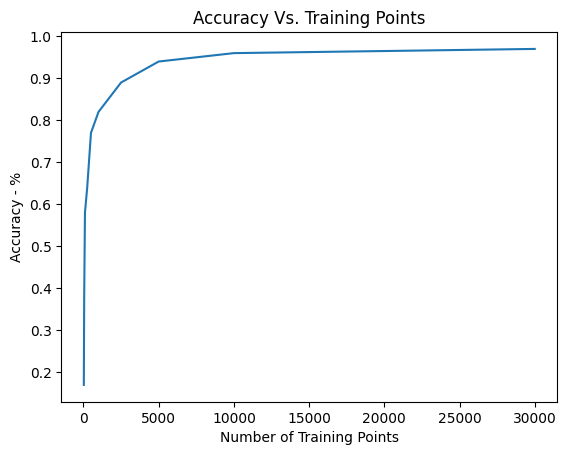

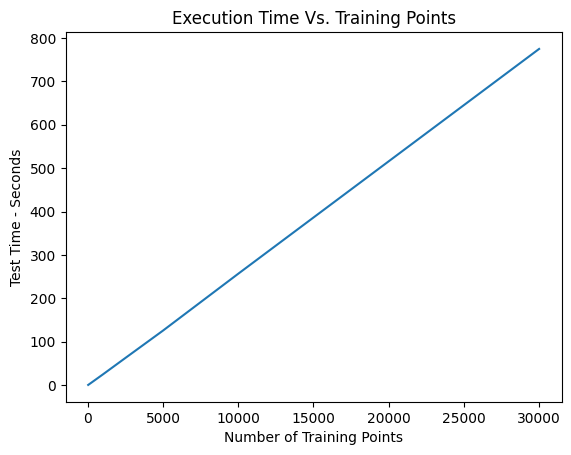

In [8]:
plt.title("Accuracy Vs. Training Points")
plt.xlabel("Number of Training Points")
plt.ylabel("Accuracy - %")
plt.plot(test_num_data_points_list, num_data_points_accuracy_list)
plt.show()
plt.title("Execution Time Vs. Training Points")
plt.xlabel("Number of Training Points")
plt.ylabel("Test Time - Seconds")
plt.plot(test_num_data_points_list, num_data_points_time_list)
plt.show()

Since efficiency is linear, to get the most out of out model, we want to find the point where accuracy improvement diminish. We can run the test again using more points in the range we are concerned with.

In [9]:
test_num_data_points_list = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000]
num_data_points_accuracy_list = [] # list to capture accuracy results

# tests each value for number for number of test points and saves test data
for num_data_points in test_num_data_points_list:
    k = 15
    model = KNeighbors(num_data_points, k, 'euclidean')
    (accuracy, execution_time) = model.test_model(100)
    num_data_points_accuracy_list.append(accuracy)

Testing Model: k: 15, metric: euclidean, data points: 1000
The model correctly categorized 82 (accuracy = 0.82) in 25.097322463989258 seconds. Average time: 0.2509732246398926
Testing Model: k: 15, metric: euclidean, data points: 1500
The model correctly categorized 88 (accuracy = 0.88) in 37.6735200881958 seconds. Average time: 0.376735200881958
Testing Model: k: 15, metric: euclidean, data points: 2000
The model correctly categorized 88 (accuracy = 0.88) in 50.12513208389282 seconds. Average time: 0.5012513208389282
Testing Model: k: 15, metric: euclidean, data points: 2500
The model correctly categorized 89 (accuracy = 0.89) in 62.80431151390076 seconds. Average time: 0.6280431151390076
Testing Model: k: 15, metric: euclidean, data points: 3000
The model correctly categorized 90 (accuracy = 0.9) in 75.31732535362244 seconds. Average time: 0.7531732535362243
Testing Model: k: 15, metric: euclidean, data points: 3500
The model correctly categorized 92 (accuracy = 0.92) in 87.620952129

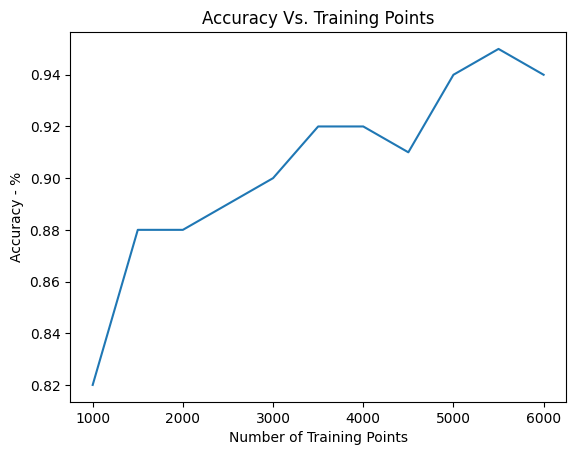

In [10]:
plt.title("Accuracy Vs. Training Points")
plt.xlabel("Number of Training Points")
plt.ylabel("Accuracy - %")
plt.plot(test_num_data_points_list, num_data_points_accuracy_list)
plt.show()

We can see that after the initial sharp increase, accuracy increases are roughly consistent between 2000 and 6000 points. Values in this range are acceptable options. A selection of 3000 data points keeps processing time per data point below 1 second and will be our selection.

Next, we consider the different possible values for k. This will be similar to the previous process for the number of data points.

In [11]:
k_list = [2, 5, 10, 15, 25, 50, 100, 150, 200, 500, 1000, 1500, 2000]
k_accuracy_list = [] # list to capture accuracy results
k_time_list = [] # list to capture execution time results

# tests each value for k and saves test data
for k in k_list:
    num_data_points = 3000
    model = KNeighbors(num_data_points, k, 'euclidean')
    (accuracy, execution_time) = model.test_model(100)
    k_accuracy_list.append(accuracy)
    k_time_list.append(execution_time)

Testing Model: k: 2, metric: euclidean, data points: 3000
The model correctly categorized 88 (accuracy = 0.88) in 75.17602586746216 seconds. Average time: 0.7517602586746216
Testing Model: k: 5, metric: euclidean, data points: 3000
The model correctly categorized 93 (accuracy = 0.93) in 75.16372299194336 seconds. Average time: 0.7516372299194336
Testing Model: k: 10, metric: euclidean, data points: 3000
The model correctly categorized 94 (accuracy = 0.94) in 75.18971180915833 seconds. Average time: 0.7518971180915832
Testing Model: k: 15, metric: euclidean, data points: 3000
The model correctly categorized 90 (accuracy = 0.9) in 75.00135684013367 seconds. Average time: 0.7500135684013367
Testing Model: k: 25, metric: euclidean, data points: 3000
The model correctly categorized 89 (accuracy = 0.89) in 75.10347366333008 seconds. Average time: 0.7510347366333008
Testing Model: k: 50, metric: euclidean, data points: 3000
The model correctly categorized 89 (accuracy = 0.89) in 75.0756025314

Above we can see that the time is constant for all values of k which is what we would expect given the algorithm. The highest observed accuracy is for $k = 10$.

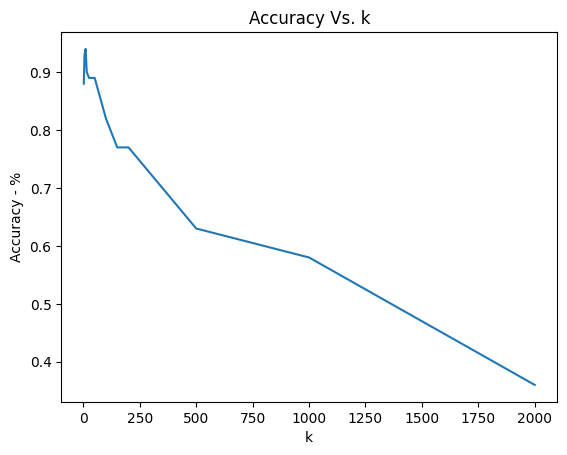

In [12]:
plt.title("Accuracy Vs. k")
plt.xlabel("k")
plt.ylabel("Accuracy - %")
plt.plot(k_list, k_accuracy_list)
plt.show()

To narrow down the best value for k, we will test the accuracy for all values of k from 6 to 14.

In [13]:
k_list = [6, 7, 8, 9, 10, 11, 12, 13, 14]

# tests each value for k and saves test data
for k in k_list:
    num_data_points = 3000
    model = KNeighbors(num_data_points, k, 'euclidean')
    model.test_model(100)

Testing Model: k: 6, metric: euclidean, data points: 3000
The model correctly categorized 92 (accuracy = 0.92) in 75.1752610206604 seconds. Average time: 0.751752610206604
Testing Model: k: 7, metric: euclidean, data points: 3000
The model correctly categorized 90 (accuracy = 0.9) in 75.202397108078 seconds. Average time: 0.75202397108078
Testing Model: k: 8, metric: euclidean, data points: 3000
The model correctly categorized 91 (accuracy = 0.91) in 75.4129843711853 seconds. Average time: 0.754129843711853
Testing Model: k: 9, metric: euclidean, data points: 3000
The model correctly categorized 90 (accuracy = 0.9) in 75.15616512298584 seconds. Average time: 0.7515616512298584
Testing Model: k: 10, metric: euclidean, data points: 3000
The model correctly categorized 94 (accuracy = 0.94) in 75.16521954536438 seconds. Average time: 0.7516521954536438
Testing Model: k: 11, metric: euclidean, data points: 3000
The model correctly categorized 90 (accuracy = 0.9) in 75.1616702079773 seconds.

This confirms that $k = 10$ gives us the best accuracy results for the Euclidean distance.

## Analysis - Cosine Distance

We now perform the same analysis for the cosine distance metric.

In [14]:
test_num_data_points_list = [25, 50, 100, 250, 500, 1000, 2500, 5000]
num_data_points_accuracy_list = [] # list to capture accuracy results
num_data_points_time_list = [] # list to capture execution time results

# tests each value for number for number of test points and saves test data
for num_data_points in test_num_data_points_list:
    k = 15
    model = KNeighbors(num_data_points, k, 'cosine')
    (accuracy, execution_time) = model.test_model(100)
    num_data_points_accuracy_list.append(accuracy)
    num_data_points_time_list.append(execution_time)

Testing Model: k: 15, metric: cosine, data points: 25
The model correctly categorized 22 (accuracy = 0.22) in 1.2736072540283203 seconds. Average time: 0.012736072540283203
Testing Model: k: 15, metric: cosine, data points: 50
The model correctly categorized 44 (accuracy = 0.44) in 2.520714044570923 seconds. Average time: 0.02520714044570923
Testing Model: k: 15, metric: cosine, data points: 100
The model correctly categorized 65 (accuracy = 0.65) in 5.029554843902588 seconds. Average time: 0.05029554843902588
Testing Model: k: 15, metric: cosine, data points: 250
The model correctly categorized 70 (accuracy = 0.7) in 12.621694087982178 seconds. Average time: 0.12621694087982177
Testing Model: k: 15, metric: cosine, data points: 500
The model correctly categorized 77 (accuracy = 0.77) in 25.86818528175354 seconds. Average time: 0.2586818528175354
Testing Model: k: 15, metric: cosine, data points: 1000
The model correctly categorized 85 (accuracy = 0.85) in 51.35305690765381 seconds. Av

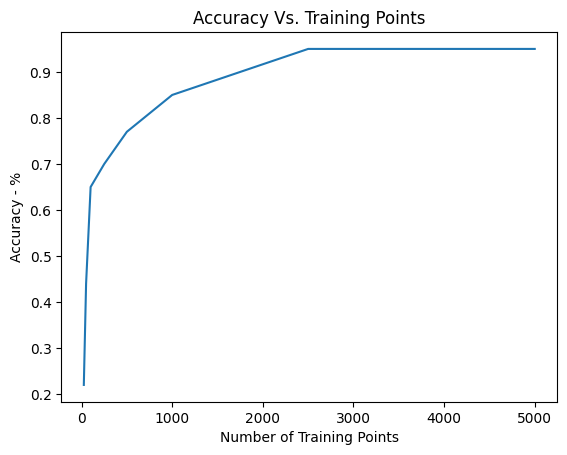

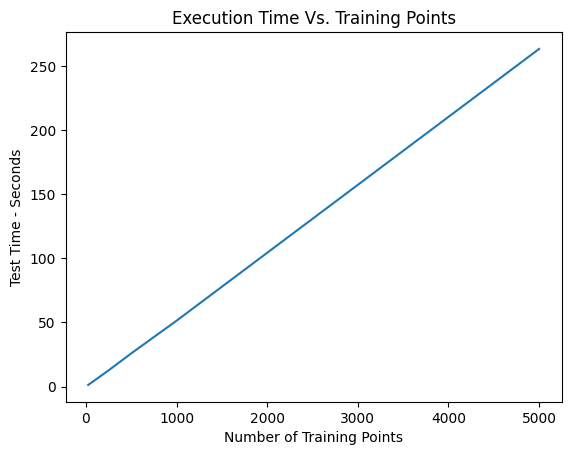

In [15]:
plt.title("Accuracy Vs. Training Points")
plt.xlabel("Number of Training Points")
plt.ylabel("Accuracy - %")
plt.plot(test_num_data_points_list, num_data_points_accuracy_list)
plt.show()
plt.title("Execution Time Vs. Training Points")
plt.xlabel("Number of Training Points")
plt.ylabel("Test Time - Seconds")
plt.plot(test_num_data_points_list, num_data_points_time_list)
plt.show()

In [16]:
test_num_data_points_list = [1000, 1500, 2000, 2500]
num_data_points_accuracy_list = [] # list to capture accuracy results
num_data_points_time_list = [] # list to capture execution time results

# tests each value for number for number of test points and saves test data
for num_data_points in test_num_data_points_list:
    k = 15
    model = KNeighbors(num_data_points, k, 'cosine')
    (accuracy, execution_time) = model.test_model(100)
    num_data_points_accuracy_list.append(accuracy)
    num_data_points_time_list.append(execution_time)

Testing Model: k: 15, metric: cosine, data points: 1000
The model correctly categorized 85 (accuracy = 0.85) in 51.397088289260864 seconds. Average time: 0.5139708828926086
Testing Model: k: 15, metric: cosine, data points: 1500
The model correctly categorized 92 (accuracy = 0.92) in 78.08760190010071 seconds. Average time: 0.7808760190010071
Testing Model: k: 15, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.45756530761719 seconds. Average time: 1.0445756530761718
Testing Model: k: 15, metric: cosine, data points: 2500
The model correctly categorized 95 (accuracy = 0.95) in 130.82997465133667 seconds. Average time: 1.3082997465133668


In [17]:
k_list = [2, 5, 10, 15, 25, 50, 100, 150, 200, 500, 1000, 1500, 2000]
k_accuracy_list = [] # list to capture accuracy results
k_time_list = [] # list to capture execution time results

# tests each value for k and saves test data
for k in k_list:
    num_data_points = 2000
    model = KNeighbors(num_data_points, k, 'cosine')
    (accuracy, execution_time) = model.test_model(100)
    k_accuracy_list.append(accuracy)
    k_time_list.append(execution_time)

Testing Model: k: 2, metric: cosine, data points: 2000
The model correctly categorized 91 (accuracy = 0.91) in 104.68769335746765 seconds. Average time: 1.0468769335746766
Testing Model: k: 5, metric: cosine, data points: 2000
The model correctly categorized 95 (accuracy = 0.95) in 103.90228796005249 seconds. Average time: 1.039022879600525
Testing Model: k: 10, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.0438802242279 seconds. Average time: 1.040438802242279
Testing Model: k: 15, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.78651022911072 seconds. Average time: 1.0478651022911072
Testing Model: k: 25, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.08021879196167 seconds. Average time: 1.0408021879196168
Testing Model: k: 50, metric: cosine, data points: 2000
The model correctly categorized 89 (accuracy = 0.89) in 103.67974185943604 seconds. 

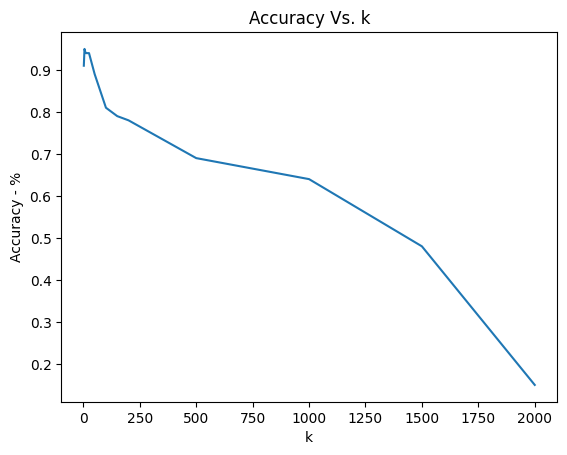

In [18]:
plt.title("Accuracy Vs. k")
plt.xlabel("k")
plt.ylabel("Accuracy - %")
plt.plot(k_list, k_accuracy_list)
plt.show()

In [25]:
k_list = [3, 4, 5, 6, 7, 8, 9]
k_accuracy_list = [] # list to capture accuracy results
k_time_list = [] # list to capture execution time results

# tests each value for k and saves test data
for k in k_list:
    num_data_points = 2000
    model = KNeighbors(num_data_points, k, 'cosine')
    (accuracy, execution_time) = model.test_model(100)
    k_accuracy_list.append(accuracy)
    k_time_list.append(execution_time)

Testing Model: k: 3, metric: cosine, data points: 2000
The model correctly categorized 93 (accuracy = 0.93) in 103.99274396896362 seconds. Average time: 1.0399274396896363
Testing Model: k: 4, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.17705059051514 seconds. Average time: 1.0417705059051514
Testing Model: k: 5, metric: cosine, data points: 2000
The model correctly categorized 95 (accuracy = 0.95) in 104.28188633918762 seconds. Average time: 1.0428188633918762
Testing Model: k: 6, metric: cosine, data points: 2000
The model correctly categorized 94 (accuracy = 0.94) in 104.44615244865417 seconds. Average time: 1.0444615244865418
Testing Model: k: 7, metric: cosine, data points: 2000
The model correctly categorized 95 (accuracy = 0.95) in 104.21860694885254 seconds. Average time: 1.0421860694885254
Testing Model: k: 8, metric: cosine, data points: 2000
The model correctly categorized 95 (accuracy = 0.95) in 104.37224125862122 seconds. A

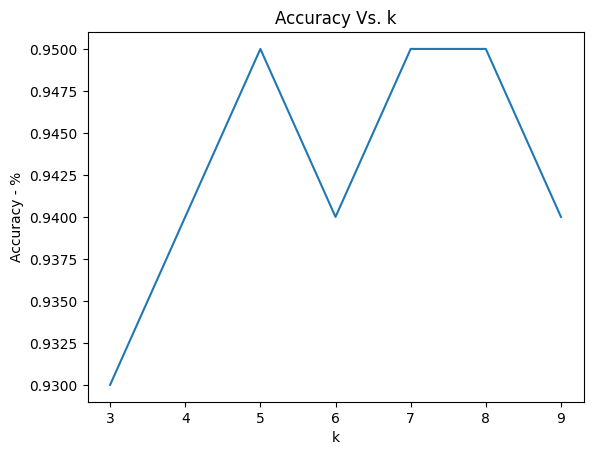

In [26]:
plt.title("Accuracy Vs. k")
plt.xlabel("k")
plt.ylabel("Accuracy - %")
plt.plot(k_list, k_accuracy_list)
plt.show()

With 2000 samples and k = 5, we get roughly a 95% accuracy rate using the cosine distance with approximately 1 second of processing time per data point. This performs better than the Euclidean distance and will be the representative algorithm for the k-nearest neighbors approach.

# Logistic Regression

Linear regression is a method for creating linear models that make predictions based on presumed linear relationships between the model's parameters. A linear regression model is of the following form where $n$ is the number of features the model considers, $a_i$ is the weight for each parameter $x_i$: $$y = b + a_1x_1 + a_2x_2 \cdots a_nx_n$$ However, we are not predicting a continuous value; we are instead trying to categorize data points. Therefore, we need a different model which is given by the sigmoid below where $\sigma$ is a vector containing the model weights and $x$ is a vector containing the parameters. The output of the sigmoid function ranges between 0 and 1 which we interpret as the probability of a positive classification. That is, the data point matches the class that the model is trained to identify.

$$h_{\sigma}(x) = \frac{1}{1+e^{-\sigma^Tx}}$$

To create the model we need to determine the weights ($\sigma$). To do this we determine a cost function which tells us how far off we are from our prediction. The cost function takes into account the binary classification of each point. $$J(\theta)=-\frac{1}{m}\sum_{i=1}^m[y^{(i)}\times log(h_\theta(x^{(i)}))+(1-y^{(i)})\times log(h_\theta(x^{(i)}))]$$

Our task is to now find the model weights which minimize the value of the loss function. To do this, we use a process called gradient descent. Gradient descent uses vector calculus to determine the steapest slope at a given point on a surface and moving in the opposite direction. Doing this recursively allows us to find a local minimum value for the function. The gradient is calculated component wise for each value of sigma using the partial derivative below:$$\frac{\partial}{\partial J(\sigma_j)}J(\sigma)=\frac{1}{m}\sum_{i=1}^m(h_\sigma (x^{(i)})-y^{(i)})x_j^{(i)}$$

For more information on gradient descent in logistic regression, visit the following website which was referenced while creating our model: https://www.baeldung.com/cs/gradient-descent-logistic-regression

## The Class

The logic discussed above can be wrapped into a class that allows us to save our training weights, test the model, and make predictions for new data points.

In [27]:
import numpy as np
import time
from keras.datasets import mnist
from keras.utils import to_categorical

# Sigmoid function that is included in the regression function h separated out for clarity
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# The regression function h which gives the probability of a specific category
def h(sigma, x):
    return sigmoid(np.dot(x, sigma))

# Performs a single gradient descent step moving the model parameters in a direction that
# decreases the cost
def gradient_descent_step(sigma, x_train, y_train, alpha):
    m = len(y_train)
    predictions = h(sigma, x_train)
    errors = predictions - y_train
    gradient = np.dot(np.array(x_train).T, errors) / m
    return sigma - alpha * gradient

# Uses the gradient_descent_step function recursively to find parameters that minimize the
# cost function
def gradient_descent(sigma, x_train, y_train, alpha, epochs):
    parameters = sigma.copy()
    for i in range(epochs):
        parameters = gradient_descent_step(parameters, x_train, y_train, alpha)
    return parameters

# Separate labels out into a binary list of labels for each digit
# 10 models are trained which require binary labels
def get_labels(train_labels):
    labels = [[] for i in range (10)]
    for label in train_labels:
        for i in range(10):
            labels[i].append(label[i])
    return labels


# Class which represents the logistic regression model used to classify digits
class LogisticRegression:
    def __init__(self):
        # Stores model parameters for each digit at the index corresponding to that digit
        # augmented to include weight for the bias term
        self.sigmas = [[0 for i in range(785)] for i in range(10)]
        # Number of training iterations used to train each model
        self.epochs = 0
        # Alpha represents the training rate. This impacts the size of each modification made
        # during each epoch
        self.alpha = 0

        # import training data and format
        NB_CLASSES = 10  # number of possible categories (10 digits)
        RESHAPED = 784  # training data is 28 x 28 pixels, will be reshaped into single vector of this size
        (X_train, y_train), (X_test, y_test) = mnist.load_data()  # load training and test data
        # reshape training and test data into single column vector
        X_train = X_train.reshape(60000, RESHAPED)
        X_test = X_test.reshape(10000, RESHAPED)
        X_train = X_train.astype('float32')
        X_test = X_test.astype('float32')
        # normalize the pixel data
        X_train /= 255
        X_test /= 255
        # Add a bias column to the data set
        X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        # perform one-hot encoding
        Y_train = to_categorical(y_train, NB_CLASSES)
        Y_test = to_categorical(y_test, NB_CLASSES)
        # load num_data_points data points with corresponding label into model
        self.vector_data = []
        vector_label = []
        for i in range(len(X_train)):
            self.vector_data.append(X_train[i])
            vector_label.append(Y_train[i])
        self.train_labels = get_labels(vector_label)

        # load test data with corresponding labels for test method
        self.vector_test = []
        for i in range(10000):
            single_vector_x_test = X_test[i]
            single_vector_y_test = Y_test[i]
            labeled_test = [single_vector_x_test, single_vector_y_test]
            self.vector_test.append(labeled_test)
    
    # Apply the gradient descent algorithm to create a model for each digit
    # Uses alpha as the training rate which determines the step size when updating weights
    # and epochs which gives us the number of training iterations
    def train(self, alpha, epochs):
        self.alpha = alpha
        self.epochs = epochs
        for i in range(len(self.sigmas)):
            print('Training model for digit ' + str(i))
            self.sigmas[i] = gradient_descent(self.sigmas[i], self.vector_data, self.train_labels[i], alpha, epochs)
    
    # Categorizes a new point using a trained model and returns a string representing the category
    def get_category(self, new_point):
        new_point = np.insert(new_point, 0, 1) # Add the bias term
        probabilities = [] # stores probabilities for each category
        for i in range(len(self.sigmas)):
            probabilities.append(h(self.sigmas[i], new_point))
        str_category = str(np.argmax(probabilities)) # selects the most likely category
        return str_category

    # Iterates over test points to determine model accuracy and efficiency
    def test_model(self, num_tests):
        print(f"Testing Model: epochs: {self.epochs}, training rate: {self.alpha}")
        # initialize variable to calculate accuracy
        cnt_correct = 0
        start_time = time.time() # start timer for comparison
        for i in range(num_tests):
            test_point = self.vector_test[i][0]
            test_label = self.vector_test[i][1]
            str_test_label = str(np.argmax(test_label))
            str_category = self.get_category(test_point)
            if str_test_label == str_category:
                cnt_correct += 1
        end_time = time.time() # stop timer
        # calculate time to categorize 10000 images
        execution_time = end_time - start_time
        # calculate accuracy
        accuracy = cnt_correct / num_tests
        # Print test results
        print(f"The model correctly categorized {cnt_correct} (accuracy = {accuracy}) in {execution_time} seconds. Average time: {execution_time / float(num_tests)}")
        return accuracy, execution_time

## Analysis

Currently, our logistic regression model is trained based on the learning rate and the number of epochs. We will train several models below to determine the optimal value for both, starting with the learning rate.

In [28]:
alpha_list = [1, 0.5, 0.1, 0.05, 0.01, 0.001]
alpha_accuracy_list = [] # list to capture accuracy results
alpha_time_list = [] # list to capture execution time results
model = LogisticRegression()

# tests each value for k and saves test data
for alpha in alpha_list:
    epochs = 500
    model.train(alpha, epochs)
    (accuracy, execution_time) = model.test_model(100)
    alpha_accuracy_list.append(accuracy)
    alpha_time_list.append(execution_time)

Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model for digit 4
Training model for digit 5
Training model for digit 6
Training model for digit 7
Training model for digit 8
Training model for digit 9
Testing Model: epochs: 500, training rate: 1
The model correctly categorized 94 (accuracy = 0.94) in 0.00589299201965332 seconds. Average time: 5.89299201965332e-05
Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model for digit 4
Training model for digit 5
Training model for digit 6
Training model for digit 7
Training model for digit 8
Training model for digit 9
Testing Model: epochs: 500, training rate: 0.5
The model correctly categorized 95 (accuracy = 0.95) in 0.005903959274291992 seconds. Average time: 5.903959274291992e-05
Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model for

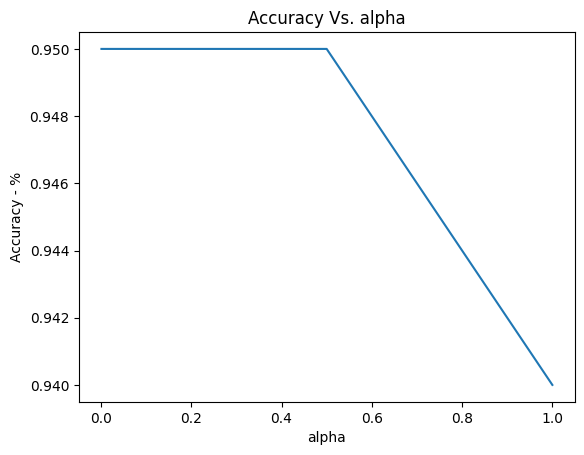

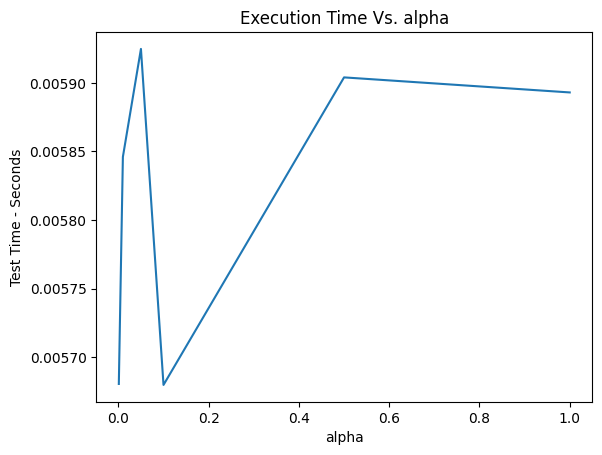

In [29]:
plt.title("Accuracy Vs. alpha")
plt.xlabel("alpha")
plt.ylabel("Accuracy - %")
plt.plot(alpha_list, alpha_accuracy_list)
plt.show()
plt.title("Execution Time Vs. alpha")
plt.xlabel("alpha")
plt.ylabel("Test Time - Seconds")
plt.plot(alpha_list, alpha_time_list)
plt.show()

From these tests, we can see that several learning rates cause the accuracy to converge. We select an alpha value of 0.5 which allows us to achieve this 95% accuracy. Testing a variable number of epochs below shows that this model tends to converge with 500 epochs of training. The logistic regression model slightly out performs the best k-nearest neighbor model tested in accuracy and greatly out performs it in efficiency. For this application, the logistic regression model is preferrable over the k-nearest neighbors algorithm.

In [32]:
epoch_list = [10, 20, 50, 75, 100, 200, 500, 1000]
epoch_accuracy_list = [] # list to capture accuracy results
epoch_time_list = [] # list to capture execution time results
model = LogisticRegression()

# tests each value for k and saves test data
for epochs in epoch_list:
    alpha = 0.5
    model.train(alpha, epochs)
    (accuracy, execution_time) = model.test_model(100)
    alpha_accuracy_list.append(accuracy)
    alpha_time_list.append(execution_time)

Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model for digit 4
Training model for digit 5
Training model for digit 6
Training model for digit 7
Training model for digit 8
Training model for digit 9
Testing Model: epochs: 10, training rate: 0.5
The model correctly categorized 79 (accuracy = 0.79) in 0.006037235260009766 seconds. Average time: 6.0372352600097656e-05
Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model for digit 4
Training model for digit 5
Training model for digit 6
Training model for digit 7
Training model for digit 8
Training model for digit 9
Testing Model: epochs: 20, training rate: 0.5
The model correctly categorized 87 (accuracy = 0.87) in 0.006071567535400391 seconds. Average time: 6.0715675354003905e-05
Training model for digit 0
Training model for digit 1
Training model for digit 2
Training model for digit 3
Training model

# Neural Network

Finally, we will further explore neural network parameters. The impact of the number of hidden layers on the model was originally explored in CS-370. More variations on the number of hidden layers will be tested along with epochs, batch size, hiden nodes per layer, and two different activation functions will be considered. Our neural network is similar to logistic regression in that a vector of weights is multiplied by a vector of network parameters on each layer. Non-linearity is introduced to the model before passing information to the next layer by applying a non-linear activation fuction to the product of the weights and parameters. The activation function of the final layer gives us the category that we are looking for.

In [46]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD
from keras.utils import to_categorical


def test_model(epochs: int, batch_size: int, hidden: int, layers: int, activation: str):
    # network and training
    NB_EPOCH = epochs
    BATCH_SIZE = batch_size
    VERBOSE = 1
    NB_CLASSES = 10  # number of outputs = number of digits
    OPTIMIZER = SGD()
    N_HIDDEN = hidden
    VALIDATION_SPLIT = 0.2  # how much TRAIN is reserved for VALIDATION
    ACTIVATION_FUNCTION_HIDDEN = activation
    # data: shuffled and split between train and tests sets
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    # X_train is 60000 rows of 28x28 values --> reshaped in 60000 x 784
    RESHAPED = 784
    X_train = X_train.reshape(60000, RESHAPED)
    X_test = X_test.reshape(10000, RESHAPED)
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')
    # normalize
    X_train /= 255
    X_test /= 255
    print(X_train.shape[0], 'train samples')
    print(X_test.shape[0], 'test samples')
    # convert class vectors to binary class matrices
    Y_train = to_categorical(y_train, NB_CLASSES)
    Y_test = to_categorical(y_test, NB_CLASSES)
    # M_HIDDEN hidden layers
    # 10 outputs
    # final state is softmax
    model = Sequential()
    for i in range(layers):
        model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
        model.add(Activation(ACTIVATION_FUNCTION_HIDDEN))
    model.add(Dense(NB_CLASSES))
    model.add(Activation('softmax'))
    model.summary()
    model.compile(loss='categorical_crossentropy', optimizer=OPTIMIZER,
                  metrics=['accuracy'])
    history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                        verbose=VERBOSE, validation_split=VALIDATION_SPLIT)
    score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
    print("Test score:", score[0])
    print('Test accuracy:', score[1])
    return score[1]

## Analysis - Activation Function ReLU

Below we evaluate each parameter for the ReLU activation function. The final test accuracy is used to determine the best performing value. At times the accuracy during training is higher than the test accuracy which could indicate model overfitting. This is why the test accuracy is the metric that we use to evaluate the models. We start with the number of hidden layers.

In [48]:
num_layers_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
accuracy_list = []

for num_layers in num_layers_list:
    epochs = 20
    batch_size = 128
    hidden = 128
    activation = 'relu'
    model_accuracy = test_model(epochs, batch_size, hidden, num_layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_179 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_179 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_180 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_180 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_233 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_233 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_234 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_234 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_235 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_235 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_236 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_237 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_237 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_238 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_238 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_239 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_239 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_240 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_240 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_241 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_241 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_242 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_243 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2120 - loss: 2.2901 - val_accuracy: 0.3160 - val_loss: 2.2682
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3086 - loss: 2.1137 - val_accuracy: 0.4507 - val_loss: 1.8088
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6084 - loss: 1.1905 - val_accuracy: 0.6693 - val_loss: 0.9335
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8131 - loss: 0.6078 - val_accuracy: 0.8691 - val_loss: 0.4447
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8749 - loss: 0.4211 - val_accuracy: 0.8956 - val_loss: 0.3451
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9051 - loss: 0.3288 - val_accuracy: 0.9221 - val_loss: 0.2707
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9210 - loss: 0.2704 - val_accuracy: 0.9320 - val_loss: 0.2365
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9322 - loss: 0.2295 - val_accuracy: 0.

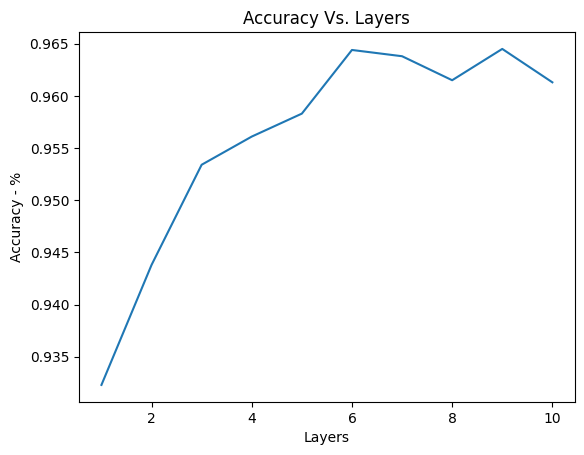

In [49]:
plt.title("Accuracy Vs. Layers")
plt.xlabel("Layers")
plt.ylabel("Accuracy - %")
plt.plot(num_layers_list, accuracy_list)
plt.show()

The best performing number of hidden layers is 6, according to this analysis. Next we determine the best performing value for number of epochs.

In [51]:
num_epochs_list = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80]
accuracy_list = []

for num_epochs in num_epochs_list:
    layers = 6
    batch_size = 128
    hidden = 128
    activation = 'relu'
    model_accuracy = test_model(num_epochs, batch_size, hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_286 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_286 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_287 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_287 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_288 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_288 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_289 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_289 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_290 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_290 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_291 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_292 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,330 (720.04 KB)

 Trainable params: 184,330 (720.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_349 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_349 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_350 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_350 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_351 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_351 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_352 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_352 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_353 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_353 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_354 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_354 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_355 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_355 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,330 (720.04 KB)

 Trainable params: 184,330 (720.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2293 - loss: 2.2152 - val_accuracy: 0.4527 - val_loss: 1.9909
Epoch 2/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6501 - loss: 1.2375 - val_accuracy: 0.8267 - val_loss: 0.6048
Epoch 3/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8538 - loss: 0.5017 - val_accuracy: 0.8843 - val_loss: 0.3956
Epoch 4/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8898 - loss: 0.3799 - val_accuracy: 0.8873 - val_loss: 0.3642
Epoch 5/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.3238 - val_accuracy: 0.9166 - val_loss: 0.2862
Epoch 6/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.2865 - val_accuracy: 0.9248 - val_loss: 0.2546
Epoch 7/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9232 - loss: 0.2581 - val_accuracy: 0.9304 - val_loss: 0.2337
Epoch 8/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9317 - loss: 0.2326 - val_accuracy: 0.

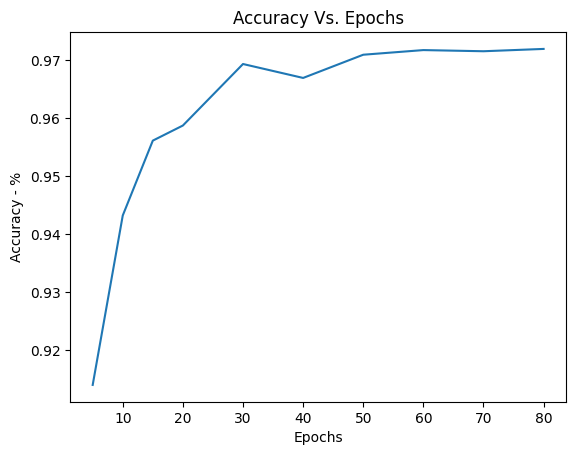

In [52]:
plt.title("Accuracy Vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy - %")
plt.plot(num_epochs_list, accuracy_list)
plt.show()

The model improvement drops off at 30 epochs. This value is selected to avoid model overfitting. Next, we evaluate training batch sizes which affects how often the model weights are updated during training.

In [53]:
batch_size_list = [32, 64, 128, 256, 512, 1024]
accuracy_list = []

for batch_size in batch_size_list:
    layers = 6
    epochs = 30
    hidden = 128
    activation = 'relu'
    model_accuracy = test_model(epochs, batch_size, hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_356 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_356 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_357 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_357 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_358 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_358 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_359 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_359 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_360 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_360 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_361 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_361 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_362 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_362 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,330 (720.04 KB)

 Trainable params: 184,330 (720.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_391 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_391 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_392 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_392 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_393 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_393 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_394 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_394 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_395 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_395 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_396 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_396 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_397 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_397 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,330 (720.04 KB)

 Trainable params: 184,330 (720.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1191 - loss: 2.2962 - val_accuracy: 0.1554 - val_loss: 2.2825
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2015 - loss: 2.2714 - val_accuracy: 0.2526 - val_loss: 2.2568
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2839 - loss: 2.2417 - val_accuracy: 0.3141 - val_loss: 2.2197
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3290 - loss: 2.1939 - val_accuracy: 0.3531 - val_loss: 2.1552
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3636 - loss: 2.1085 - val_accuracy: 0.3970 - val_loss: 2.0403
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4144 - loss: 1.9627 - val_accuracy: 0.4578 - val_loss: 1.8527
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4755 - loss: 1.7399 - val_accuracy: 0.5291 - val_loss: 1.5873
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 1.4606 - val_accuracy: 0.6472 - val_loss

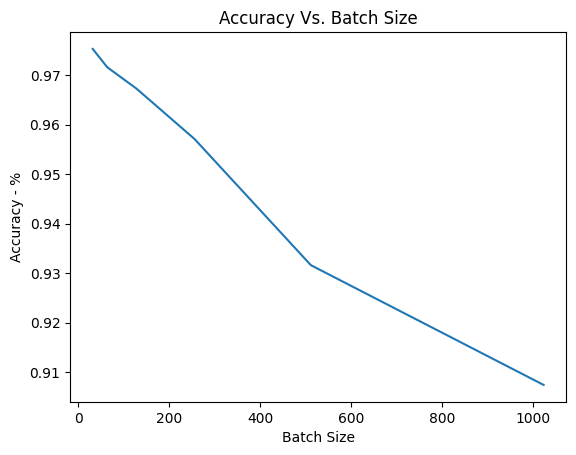

In [54]:
plt.title("Accuracy Vs. Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy - %")
plt.plot(batch_size_list, accuracy_list)
plt.show()

The smallest batch size examined was 32 and performed the best. We will use this value for the parameter. Finally, we will consider the number of nodes per layer.

In [55]:
num_hidden_list = [32, 64, 128, 256, 512, 1024]
accuracy_list = []

for num_hidden in num_hidden_list:
    batch_size = 32
    layers = 6
    epochs = 30
    activation = 'relu'
    model_accuracy = test_model(epochs, batch_size, num_hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_398 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_398 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_399 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_399 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_400 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_400 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_401 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_401 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_402 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_402 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_403 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_403 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_404 (Dense)               │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_404 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_433 (Dense)               │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_433 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_434 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_434 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_435 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_435 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_436 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_436 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_437 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_437 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_438 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_438 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_439 (Dense)               │ (None, 10)             │        10,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_439 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,062,090 (23.13 MB)

 Trainable params: 6,062,090 (23.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8030 - loss: 0.7004 - val_accuracy: 0.9265 - val_loss: 0.2505
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9344 - loss: 0.2226 - val_accuracy: 0.9544 - val_loss: 0.1610
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9537 - loss: 0.1559 - val_accuracy: 0.9600 - val_loss: 0.1407
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9658 - loss: 0.1172 - val_accuracy: 0.9624 - val_loss: 0.1295
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9727 - loss: 0.0925 - val_accuracy: 0.9677 - val_loss: 0.1092
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9779 - loss: 0.0730 - val_accuracy: 0.9613 - val_loss: 0.1331
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.9707 - val_loss: 0.0968
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9871 -

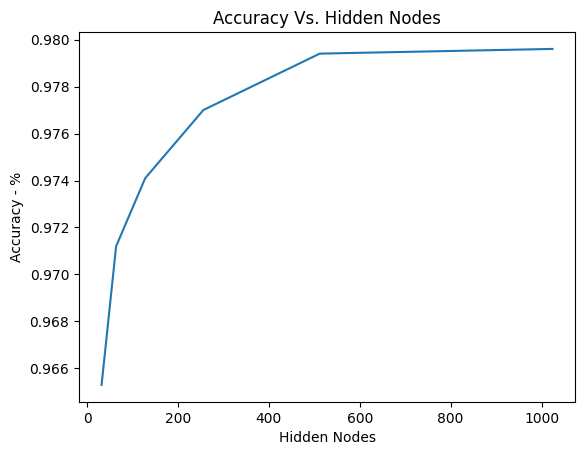

In [56]:
plt.title("Accuracy Vs. Hidden Nodes")
plt.xlabel("Hidden Nodes")
plt.ylabel("Accuracy - %")
plt.plot(num_hidden_list, accuracy_list)
plt.show()

Model improvements drop off after 512 hidden nodes per layer. We will use 512 nodes for the model. Below is the best obseved model for the ReLU activation function. Our model achieves almost 98% accuracy.

In [57]:
layers = 6
epochs = 30
batch_size = 32
activation = 'relu'
num_hidden = 512
test_model(epochs, batch_size, num_hidden, layers, activation)

60000 train samples
10000 test samples


Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_440 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_440 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_441 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_441 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_442 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_442 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_443 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_443 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_444 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_444 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_445 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_445 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_446 (Dense)               │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_446 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,720,330 (6.56 MB)

 Trainable params: 1,720,330 (6.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7875 - loss: 0.7362 - val_accuracy: 0.9164 - val_loss: 0.2791
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9294 - loss: 0.2386 - val_accuracy: 0.9435 - val_loss: 0.1936
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9499 - loss: 0.1700 - val_accuracy: 0.9519 - val_loss: 0.1571
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9622 - loss: 0.1284 - val_accuracy: 0.9650 - val_loss: 0.1210
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9693 - loss: 0.1016 - val_accuracy: 0.9641 - val_loss: 0.1170
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9755 - loss: 0.0828 - val_accuracy: 0.9622 - val_loss: 0.1253
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9796 - loss: 0.0685 - val_accuracy: 0.9695 - val_loss: 0.0984
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9832 - loss: 0.0566 -

0.9782999753952026

## Analysis - Activation Function tanh

We will repeat the above analysis for the tanh activation function and select the best observed model in terms of accuracy.

In [58]:
num_layers_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
accuracy_list = []

for num_layers in num_layers_list:
    epochs = 20
    batch_size = 128
    hidden = 128
    activation = 'tanh'
    model_accuracy = test_model(epochs, batch_size, hidden, num_layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_447 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_447 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_448 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_448 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_501 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_501 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_502 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_502 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_503 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_503 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_504 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_504 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_505 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_505 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_506 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_506 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_507 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_507 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_508 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_508 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_509 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_509 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_510 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_510 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_511 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_511 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7304 - loss: 0.9840 - val_accuracy: 0.8765 - val_loss: 0.4902
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8850 - loss: 0.4270 - val_accuracy: 0.9038 - val_loss: 0.3484
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9042 - loss: 0.3382 - val_accuracy: 0.9158 - val_loss: 0.2992
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9155 - loss: 0.2933 - val_accuracy: 0.9237 - val_loss: 0.2667
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9244 - loss: 0.2618 - val_accuracy: 0.9303 - val_loss: 0.2433
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9321 - loss: 0.2357 - val_accuracy: 0.9363 - val_loss: 0.2252
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9383 - loss: 0.2136 - val_accuracy: 0.9434 - val_loss: 0.2035
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9430 - loss: 0.1947 - val_accuracy: 0.

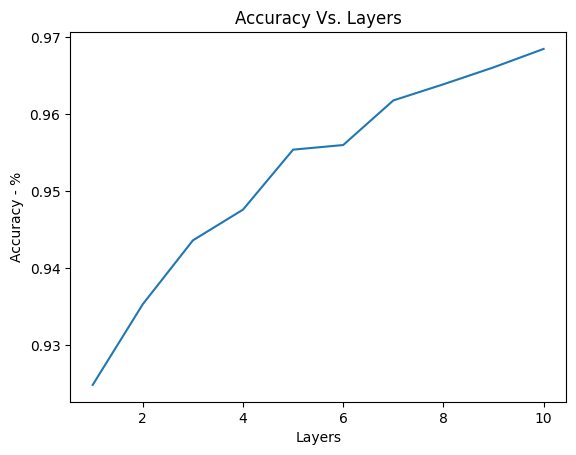

In [59]:
plt.title("Accuracy Vs. Layers")
plt.xlabel("Layers")
plt.ylabel("Accuracy - %")
plt.plot(num_layers_list, accuracy_list)
plt.show()

Accuracy increases are roughly linear with respect to the number of hidden layers. We will use the largest number of hidden layers considered which is 10.

In [61]:
num_epochs_list = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80]
accuracy_list = []

for num_epochs in num_epochs_list:
    layers = 10
    batch_size = 128
    hidden = 128
    activation = 'tanh'
    model_accuracy = test_model(num_epochs, batch_size, hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_561 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_561 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_562 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_562 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_563 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_563 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_564 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_564 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_565 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_565 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_566 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_566 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_567 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_567 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_568 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_568 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_569 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_569 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_570 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_570 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_571 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_571 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_660 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_660 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_661 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_661 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_662 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_662 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_663 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_663 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_664 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_664 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_665 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_665 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_666 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_666 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_667 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_667 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_668 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_668 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_669 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_669 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_670 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_670 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7451 - loss: 0.9757 - val_accuracy: 0.8765 - val_loss: 0.4916
Epoch 2/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8873 - loss: 0.4243 - val_accuracy: 0.9035 - val_loss: 0.3536
Epoch 3/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9058 - loss: 0.3371 - val_accuracy: 0.9158 - val_loss: 0.3014
Epoch 4/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9166 - loss: 0.2928 - val_accuracy: 0.9245 - val_loss: 0.2687
Epoch 5/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9260 - loss: 0.2611 - val_accuracy: 0.9291 - val_loss: 0.2456
Epoch 6/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9330 - loss: 0.2348 - val_accuracy: 0.9370 - val_loss: 0.2222
Epoch 7/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9387 - loss: 0.2127 - val_accuracy: 0.9413 - val_loss: 0.2065
Epoch 8/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9448 - loss: 0.1930 - val_accuracy: 0.

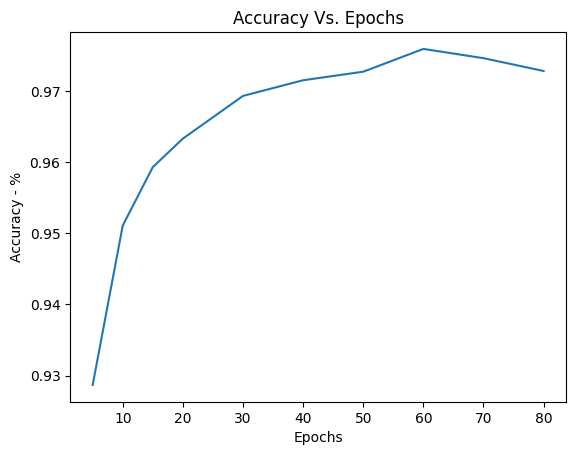

In [62]:
plt.title("Accuracy Vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy - %")
plt.plot(num_epochs_list, accuracy_list)
plt.show()

Like before, improvements drop off around 30 epochs, so we will choose 30 epochs to avoid overfitting.

In [63]:
batch_size_list = [32, 64, 128, 256, 512, 1024]
accuracy_list = []

for batch_size in batch_size_list:
    layers = 10
    epochs = 30
    hidden = 128
    activation = 'tanh'
    model_accuracy = test_model(epochs, batch_size, hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_94"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_671 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_671 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_672 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_672 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_673 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_673 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_674 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_674 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_675 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_675 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_676 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_676 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_677 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_677 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_678 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_678 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_679 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_679 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_680 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_680 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_681 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_681 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_726 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_726 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_727 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_727 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_728 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_728 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_729 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_729 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_730 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_730 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_731 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_731 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_732 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_732 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_733 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_733 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_734 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_734 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_735 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_735 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_736 (Dense)               │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_736 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,378 (978.04 KB)

 Trainable params: 250,378 (978.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4435 - loss: 1.8611 - val_accuracy: 0.6188 - val_loss: 1.5031
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6524 - loss: 1.3076 - val_accuracy: 0.7212 - val_loss: 1.0991
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7397 - loss: 1.0063 - val_accuracy: 0.7852 - val_loss: 0.8738
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7917 - loss: 0.8299 - val_accuracy: 0.8204 - val_loss: 0.7352
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8221 - loss: 0.7134 - val_accuracy: 0.8445 - val_loss: 0.6391
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8432 - loss: 0.6288 - val_accuracy: 0.8611 - val_loss: 0.5683
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8564 - loss: 0.5655 - val_accuracy: 0.8709 - val_loss: 0.5153
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8670 - loss: 0.5173 - val_accuracy: 0.8788 - v

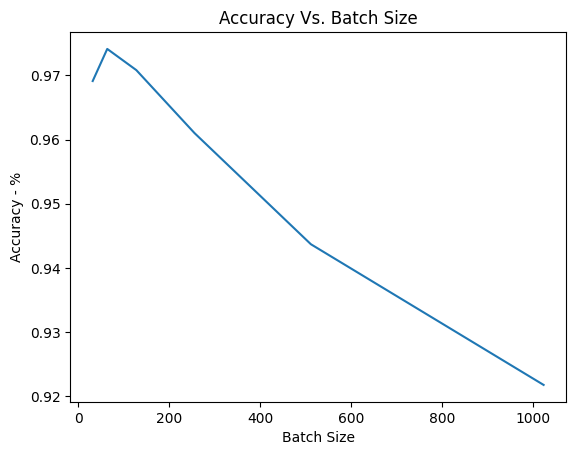

In [64]:
plt.title("Accuracy Vs. Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Accuracy - %")
plt.plot(batch_size_list, accuracy_list)
plt.show()

A batch size of 64 had the best performance for our model.

In [65]:
num_hidden_list = [32, 64, 128, 256, 512, 1024]
accuracy_list = []

for num_hidden in num_hidden_list:
    batch_size = 64
    layers = 10
    epochs = 30
    activation = 'tanh'
    model_accuracy = test_model(epochs, batch_size, num_hidden, layers, activation)
    accuracy_list.append(model_accuracy)

60000 train samples
10000 test samples


Model: "sequential_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_737 (Dense)               │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_737 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_738 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_738 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_739 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_739 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_740 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_740 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_741 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_741 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_742 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_742 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_743 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_743 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_744 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_744 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_745 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_745 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_746 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_746 (Activation)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_747 (Dense)               │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_747 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,954 (136.54 KB)

 Trainable params: 34,954 (136.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_792 (Dense)               │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_792 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_793 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_793 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_794 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_794 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_795 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_795 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_796 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_796 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_797 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_797 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_798 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_798 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_799 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_799 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_800 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_800 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_801 (Dense)               │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_801 (Activation)     │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_802 (Dense)               │ (None, 10)             │        10,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_802 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,260,490 (39.14 MB)

 Trainable params: 10,260,490 (39.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.8820 - loss: 0.4231 - val_accuracy: 0.9175 - val_loss: 0.2810
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9195 - loss: 0.2747 - val_accuracy: 0.9265 - val_loss: 0.2479
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9314 - loss: 0.2323 - val_accuracy: 0.9412 - val_loss: 0.2116
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9420 - loss: 0.1971 - val_accuracy: 0.9493 - val_loss: 0.1844
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9496 - loss: 0.1692 - val_accuracy: 0.9518 - val_loss: 0.1691
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9552 - loss: 0.1483 - val_accuracy: 0.9570 - val_loss: 0.1487
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9604 - loss: 0.1301 - val_accuracy: 0.9593 - val_loss: 0.1397
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9653 - loss: 0.1151 - 

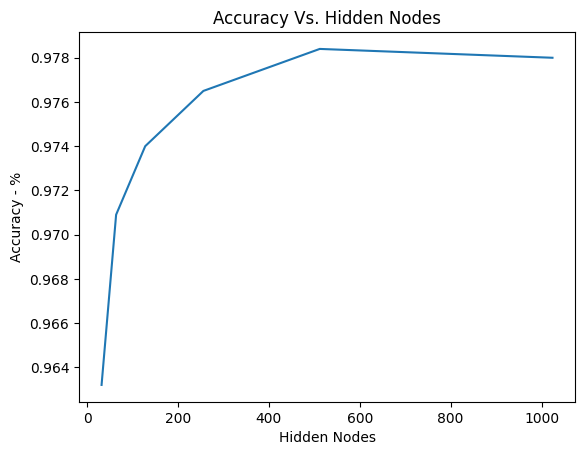

In [66]:
plt.title("Accuracy Vs. Hidden Nodes")
plt.xlabel("Hidden Nodes")
plt.ylabel("Accuracy - %")
plt.plot(num_hidden_list, accuracy_list)
plt.show()

Our accuracy peaks at 512 hidden nodes. Our best performing model using the tanh activation function is below.

In [67]:
layers = 10
epochs = 30
batch_size = 64
activation = 'tanh'
num_hidden = 512
test_model(epochs, batch_size, num_hidden, layers, activation)

60000 train samples
10000 test samples


Model: "sequential_106"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_803 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_803 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_804 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_804 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_805 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_805 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_806 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_806 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_807 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_807 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_808 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_808 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_809 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_809 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_810 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_810 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_811 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_811 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_812 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_812 (Activation)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_813 (Dense)               │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_813 (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,770,954 (10.57 MB)

 Trainable params: 2,770,954 (10.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8717 - loss: 0.4739 - val_accuracy: 0.9153 - val_loss: 0.2906
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9197 - loss: 0.2760 - val_accuracy: 0.9311 - val_loss: 0.2445
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9322 - loss: 0.2296 - val_accuracy: 0.9384 - val_loss: 0.2106
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9428 - loss: 0.1940 - val_accuracy: 0.9491 - val_loss: 0.1780
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9497 - loss: 0.1668 - val_accuracy: 0.9534 - val_loss: 0.1643
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9569 - loss: 0.1443 - val_accuracy: 0.9592 - val_loss: 0.1444
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9614 - loss: 0.1284 - val_accuracy: 0.9579 - val_loss: 0.1449
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9659 - loss: 0.1130 - val_acc

0.9746999740600586

# Conclusion

While we did not explore every combination of machine learning algorithm parameters, we were able to explore several models some of which were implemented with code specific to the project and others which made use of the keras machine learning library. The best model identified had roughly 98% accuracy and was a sequential neural network using the ReLU activation function. This model will be used in a CLI application that will allow users to identify their own handwritten digits.